# River admin

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [82]:
from io import BytesIO

import ocha_stratus as stratus
import geopandas as gpd
import matplotlib.pyplot as plt

from src.datasources import codab
from src.constants import *

In [3]:
adm3 = codab.load_codab_from_blob(admin_level=3)

In [7]:
blob_name = f"{PROJECT_PREFIX}/processed/hydrosheds/niger_river.shp"
gdf_river = stratus.load_shp_from_blob(blob_name)

In [9]:
gdf_river.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [12]:
river_aoi = gpd.sjoin(gdf_river, adm3, how="inner", predicate="intersects")

<Axes: >

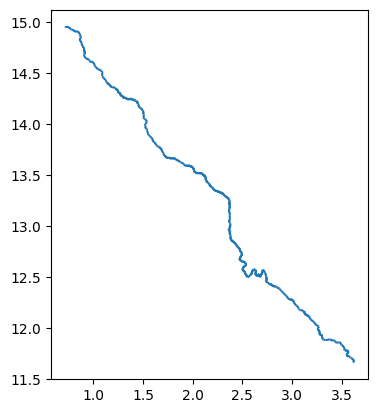

In [13]:
river_aoi.plot()

In [14]:
distance = 20

In [15]:
gdf_river_buffer = river_aoi.to_crs(3857).buffer(distance * 1000).to_crs(4326)

<Axes: >

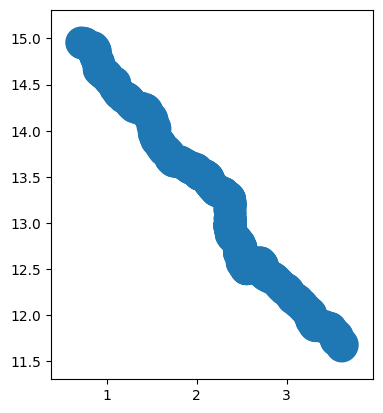

In [16]:
gdf_river_buffer.plot()

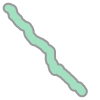

In [20]:
gdf_river_buffer.union_all()

In [68]:
adm3_clipped = gpd.clip(adm3, gdf_river_buffer.union_all())

In [84]:
adm3["target"] = adm3["ADM3_PCODE"].isin(ADM3_AOI_PCODES_2025)

In [86]:
adm3["target"].sum()

13

In [104]:
row.geometry.centroid.x

3.134765884514488

Text(0.5, 1.0, 'Communes ciblées\nFleuve Niger avec tampon de 20 km')

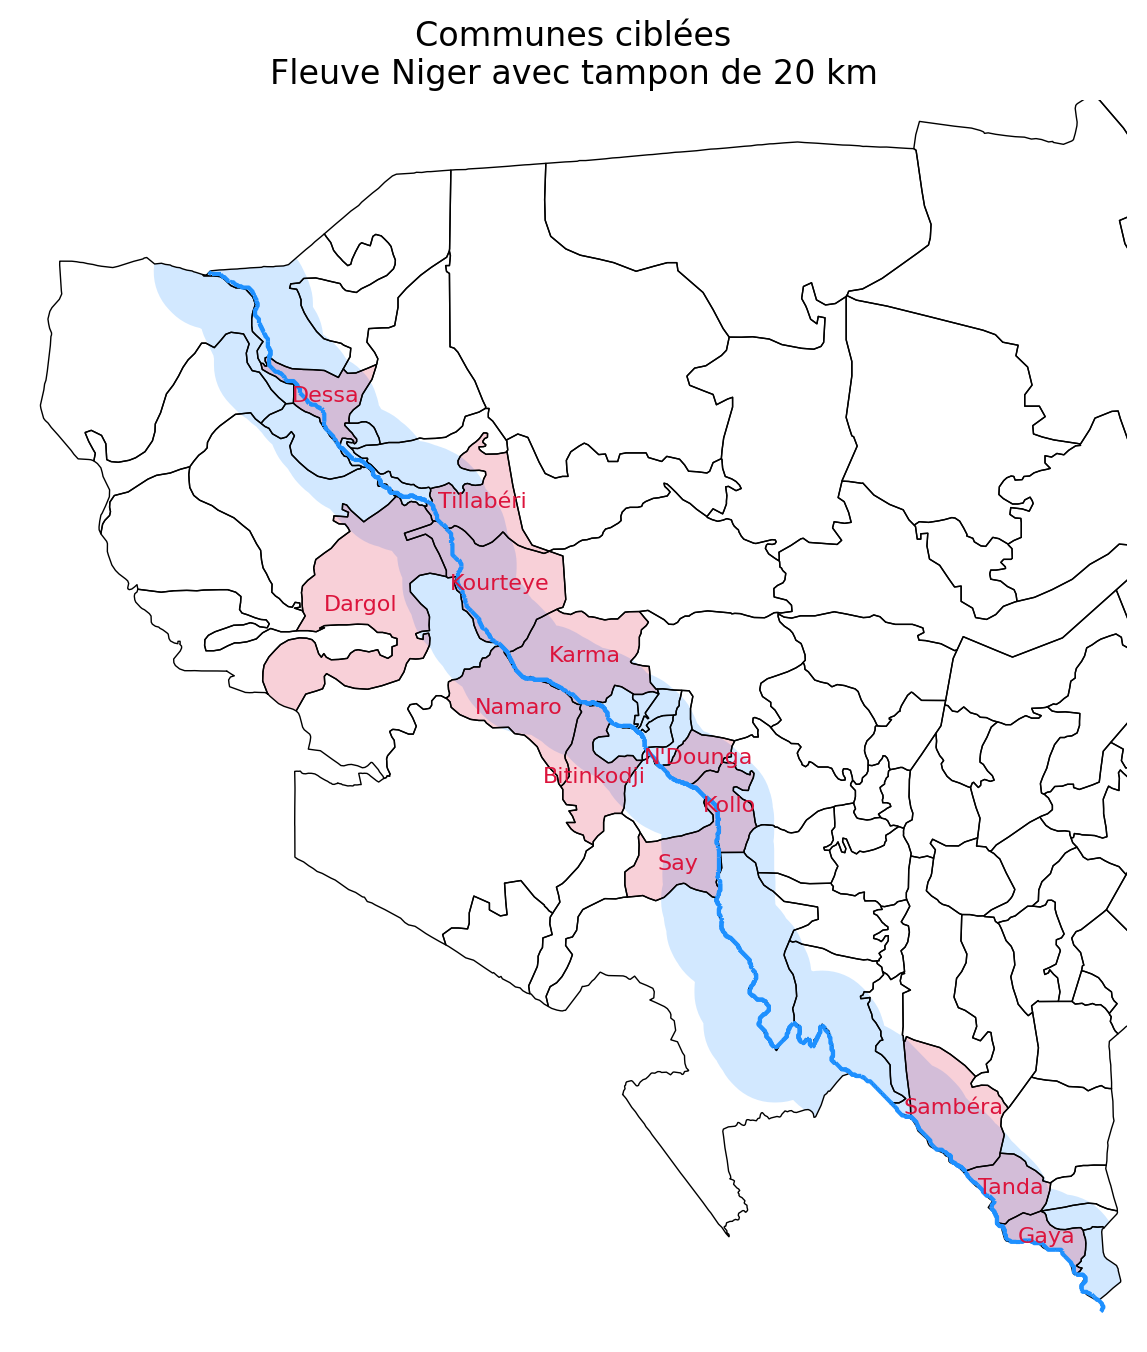

In [111]:
fig, ax = plt.subplots(dpi=200, figsize=(8, 8))

adm3.boundary.plot(ax=ax, linewidth=0.5, color="k")

adm3_clipped.plot(ax=ax, linewidth=0, color="dodgerblue", alpha=0.2)
river_aoi.plot(ax=ax, color="dodgerblue")

adm3[adm3["target"]].plot(linewidth=0, color="crimson", alpha=0.2, ax=ax)

for _, row in adm3[adm3["target"]].iterrows():
    c = row.geometry.centroid
    ax.annotate(
        row["ADM3_FR"],
        (c.x, c.y),
        va="center",
        ha="center",
        color="crimson",
        fontsize=8,
    )

ax.set_xlim(0.1, 3.7)
ax.set_ylim(11.6, 15.5)
ax.axis("off")
ax.set_title(f"Communes ciblées\nFleuve Niger avec tampon de {distance} km")

<Axes: >

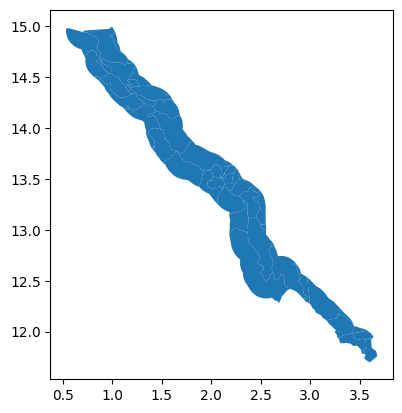

In [70]:
adm3_clipped.plot()

In [77]:
for adm_level in [1, 2, 3]:
    adm3_clipped[f"adm{adm_level}_id"] = adm3_clipped[f"ADM{adm_level}_PCODE"]
    adm3_clipped[f"adm{adm_level}_src"] = adm3_clipped[f"ADM{adm_level}_PCODE"]
    adm3_clipped[f"adm{adm_level}_name"] = adm3_clipped[f"ADM{adm_level}_FR"]

In [78]:
adm3_clipped

,ADM3_FR,ADM3_PCODE,ADM2_FR,ADM2_PCODE,ADM1_FR,ADM1_PCODE,ADM0_FR,ADM0_PCODE,DATE,VALIDON,...,geometry,adm1_id,adm1_name,adm2_id,adm2_name,adm3_id,adm3_name,adm1_src,adm2_src,adm3_src
61,Tounouga,NE003006005,Gaya,NE003006,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,...,"POLYGON ((3.62123 11.86859, 3.62258 11.85249, ...",NE003,Dosso,NE003006,Gaya,NE003006005,Tounouga,NE003,NE003006,NE003006005
59,Gaya,NE003006003,Gaya,NE003006,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,...,"POLYGON ((3.52267 11.79219, 3.51967 11.80433, ...",NE003,Dosso,NE003006,Gaya,NE003006003,Gaya,NE003,NE003006,NE003006003
58,Bengou,NE003006002,Gaya,NE003006,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,...,"POLYGON ((3.62543 11.92974, 3.62048 11.93347, ...",NE003,Dosso,NE003006,Gaya,NE003006002,Bengou,NE003,NE003006,NE003006002
60,Tanda,NE003006004,Gaya,NE003006,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,...,"POLYGON ((3.2688 11.97293, 3.26253 11.98239, 3...",NE003,Dosso,NE003006,Gaya,NE003006004,Tanda,NE003,NE003006,NE003006004
57,Bana,NE003006001,Gaya,NE003006,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,...,"POLYGON ((3.57349 12.00787, 3.54712 12.00427, ...",NE003,Dosso,NE003006,Gaya,NE003006001,Bana,NE003,NE003006,NE003006001
62,Yélou,NE003006006,Gaya,NE003006,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,...,"POLYGON ((3.4317 12.0769, 3.4259 12.07892, 3.4...",NE003,Dosso,NE003006,Gaya,NE003006006,Yélou,NE003,NE003006,NE003006006
51,Sambéra,NE003004008,Dosso,NE003004,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,...,"POLYGON ((3.15238 12.12154, 3.1433 12.12802, 3...",NE003,Dosso,NE003004,Dosso,NE003004008,Sambéra,NE003,NE003004,NE003004008
56,Guilladjé,NE003005002,Falmey,NE003005,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,...,"POLYGON ((2.98397 12.28403, 2.9814 12.28594, 2...",NE003,Dosso,NE003005,Falmey,NE003005002,Guilladjé,NE003,NE003005,NE003005002
55,Falmey,NE003005001,Falmey,NE003005,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,...,"POLYGON ((2.86664 12.38977, 2.85729 12.39553, ...",NE003,Dosso,NE003005,Falmey,NE003005001,Falmey,NE003,NE003005,NE003005001
47,Gollé,NE003004004,Dosso,NE003004,Dosso,NE003,Niger (the),NE,2023-06-21,2023-07-25,...,"POLYGON ((2.97791 12.52069, 2.97388 12.51929, ...",NE003,Dosso,NE003004,Dosso,NE003004004,Gollé,NE003,NE003004,NE003004004


In [79]:
def upload_geoparquet_to_blob(gdf, blob_name, stage="dev"):
    buffer = BytesIO()
    gdf.to_parquet(buffer, index=False)
    buffer.seek(0)
    stratus.upload_blob_data(
        data=buffer.getvalue(),
        blob_name=blob_name,
        stage=stage,
    )

In [80]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/codab/adm3_river_buffer_{distance}km.parquet"
)
upload_geoparquet_to_blob(adm3_clipped, blob_name)

In [81]:
blob_name

'pa-aa-ner-flooding/processed/codab/adm3_river_buffer_20km.parquet'